In [ ]:
!pip install tsai

In [ ]:
# 0) Imports & Drive Mount
import numpy as np
import torch
import pandas as pd
from IPython.display import display
from pathlib import Path

from tsai.all import *
from sklearn.metrics import accuracy_score, confusion_matrix
from fastai.losses import CrossEntropyLossFlat
from sklearn.metrics import accuracy_score

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# 1) Config
base = Path("/content/drive/MyDrive/Colab Notebooks/jitter/final_graph")

# Thresholds
MEAN_LOW_THR, MEAN_HIGH_THR = 10, 12
STD_LOW_THR,  STD_HIGH_THR  = 5, 7

# Window / Split (split은 모델 학습에만 사용)
train_ratio = 0.7
window_size = 64
stride      = 4

# Threshold 전용 window 설정
THR_WINDOW_SIZE = 32
THR_STRIDE      = 1


# Attack percentages
attack_pcts = list(range(10, 101, 10))

# Training params
EPOCHS_TST1  = 20
EPOCHS_TST2  = 20
LR_MAX       = 3e-3
WEIGHT_DECAY = 1e-2
BS           = 64

In [ ]:
# 2) File utils

def resolve_mix_path(base: Path, normal_pct: int, attack_pct: int) -> Path:
    """normal{n}_attack{a}.txt 규칙 기반"""
    path = base / f"normal{normal_pct}_attack{attack_pct}.txt"
    if not path.exists():
        raise FileNotFoundError(f"Not found: {path}")
    return path

def load_2ch_series(path: Path) -> np.ndarray:
    """(T,2) float32: [jitter_ms, std_jitter_ms]"""
    data = np.genfromtxt(path, delimiter="\t", names=True, dtype=float, encoding="utf-8")
    X = np.column_stack([data["jitter_ms"], data["std_jitter_ms"]]).astype(np.float32)
    return X


In [ ]:
# 3) Windowing / Split / Diff-channel
def sliding_window(x_tc: np.ndarray, L: int, stride: int) -> np.ndarray:
    """
    x_tc: (T,C)
    return: (N,L,C)
    """
    T = len(x_tc)
    n = (T - L) // stride + 1
    if n <= 0:
        raise ValueError(f"Time series too short for windowing: T={T}, L={L}, stride={stride}")
    return np.stack([x_tc[i*stride:i*stride+L] for i in range(n)], axis=0)

def split_and_window(series_2ch: np.ndarray, train_ratio: float, L: int, stride: int):
    """time split -> window (모델 학습/검증용)"""
    T = len(series_2ch)
    cut = int(T * train_ratio)
    tr_seg = series_2ch[:cut]
    va_seg = series_2ch[cut:]
    X_tr = sliding_window(tr_seg, L, stride)
    X_va = sliding_window(va_seg, L, stride)
    return X_tr, X_va

def add_diff(X_nlc: np.ndarray) -> np.ndarray:
    """
    X_nlc: (N,L,C)
    diff를 채널로 추가 -> (N,L,2C)
    """
    d = np.diff(X_nlc, axis=1, prepend=X_nlc[:, :1, :])
    X = np.concatenate([X_nlc, d], axis=2)
    return X.astype(np.float32)

def build_Xy_splits(normal_2ch: np.ndarray, attack_2ch: np.ndarray):
    """
    (모델 학습/검증용)
    - normal/attack 각각 time split -> window
    - train: normal_tr + attack_tr
    - valid: normal_va + attack_va
    - diff 채널 추가
    - tsai 포맷: (N,C,L) with C=4
    - splits: (train_idx, valid_idx)
    """
    Xn_tr, Xn_va = split_and_window(normal_2ch, train_ratio, window_size, stride)
    Xa_tr, Xa_va = split_and_window(attack_2ch, train_ratio, window_size, stride)

    # X: (N,L,C)
    X_tr = np.concatenate([Xn_tr, Xa_tr], axis=0)
    X_va = np.concatenate([Xn_va, Xa_va], axis=0)

    # y
    y_tr = np.concatenate([np.zeros(len(Xn_tr)), np.ones(len(Xa_tr))]).astype(np.int64)
    y_va = np.concatenate([np.zeros(len(Xn_va)), np.ones(len(Xa_va))]).astype(np.int64)

    # diff channels
    X_tr = add_diff(X_tr)
    X_va = add_diff(X_va)

    # to (N,C,L)
    X_tr = X_tr.transpose(0, 2, 1)
    X_va = X_va.transpose(0, 2, 1)

    # concat full
    X = np.concatenate([X_tr, X_va], axis=0).astype(np.float32)
    y = np.concatenate([y_tr, y_va], axis=0).astype(np.int64)

    n_tr = len(X_tr)
    train_idx = np.arange(0, n_tr)
    valid_idx = np.arange(n_tr, len(X))
    splits = (L(train_idx.tolist()), L(valid_idx.tolist()))
    return X, y, splits


# 임계값 평가 전용: split 없이 전체 데이터 사용
def window_all_2ch(series_2ch: np.ndarray, L: int, stride: int) -> np.ndarray:
    """
    series_2ch: (T,2)
    return: X (N,2,L)  (임계값은 원본 2채널만 사용)
    """
    X_nlc = sliding_window(series_2ch, L, stride)
    X_ncl = X_nlc.transpose(0, 2, 1).astype(np.float32)
    return X_ncl

def build_Xy_for_threshold(normal_2ch: np.ndarray, attack_2ch: np.ndarray, L: int, stride: int):
    """
    (임계값 평가용)
    - 정상/공격 전체 시계열을 그대로 윈도우로 만들고
    - 정상=0, 공격=1 라벨 부여
    - return: X (N,2,L), y (N,)
    """
    Xn = window_all_2ch(normal_2ch, L, stride)   # (Nn,2,L)
    Xa = window_all_2ch(attack_2ch, L, stride)   # (Na,2,L)
    yn = np.zeros(len(Xn), dtype=np.int64)
    ya = np.ones(len(Xa), dtype=np.int64)
    X = np.concatenate([Xn, Xa], axis=0)
    y = np.concatenate([yn, ya], axis=0)
    return X, y

In [ ]:
# 4) Threshold predictors

def threshold_predict_mean(X_windowed, low=MEAN_LOW_THR, high=MEAN_HIGH_THR, use='mean'):
    # 채널0 = jitter_ms
    jitter = X_windowed[:, 0, :]  # (N,L)
    if use == 'mean':
        stat = jitter.mean(axis=1)
    elif use == 'median':
        stat = np.median(jitter, axis=1)
    elif use == 'last':
        stat = jitter[:, -1]
    else:
        raise ValueError("use must be one of ['mean','median','last']")
    return np.where((stat >= low) & (stat <= high), 0, 1).astype(np.int64)

def threshold_predict_std(X_windowed, low=STD_LOW_THR, high=STD_HIGH_THR, use='mean'):
    # 채널1 = std_jitter_ms
    std_chan = X_windowed[:, 1, :]  # (N,L)
    if use == 'mean':
        stat = std_chan.mean(axis=1)
    elif use == 'median':
        stat = np.median(std_chan, axis=1)
    elif use == 'last':
        stat = std_chan[:, -1]
    else:
        raise ValueError("use must be one of ['mean','median','last']")
    return np.where((stat >= low) & (stat <= high), 0, 1).astype(np.int64)

In [ ]:
# 5) Model train/eval
# =========================================
def train_tst_model(X, y, splits, epochs=20):
    """
    모델 이름은 TST로 부르지만 실제는 InceptionTimePlus 유지.
    - tfms는 [None, TSClassification()] 사용
    """
    dsets = TSDatasets(X, y, splits=splits, tfms=[None, TSClassification()], inplace=True)
    dls = TSDataLoaders.from_dsets(
        dsets.train, dsets.valid,
        bs=BS, num_workers=0,
        batch_tfms=[TSStandardize()]
    )

    model = InceptionTimePlus(dls.vars, dls.c)
    learn = Learner(dls, model, loss_func=CrossEntropyLossFlat(), metrics=[accuracy])
    learn.fit_one_cycle(epochs, lr_max=LR_MAX, wd=WEIGHT_DECAY)
    return learn

def eval_learn_on_valid(learn):
    preds, targets = learn.get_preds(ds_idx=1)  # valid
    y_pred = preds.argmax(dim=1).cpu().numpy()
    y_true = targets.cpu().numpy()
    return accuracy_score(y_true, y_pred)

def predict_on_array_with_labels(learn, Xv, yv, bs=BS):
    """
    dls.test_dl(Xv) 대신:
    - valid_ds.add_test(Xv, yv)로 test dataset 생성
    - dls.valid.new(...)로 dataloader 생성
    """
    Xv = np.asarray(Xv, dtype=np.float32)
    yv = np.asarray(yv, dtype=np.int64)

    test_ds = learn.dls.valid_ds.add_test(Xv, yv)
    test_dl = learn.dls.valid.new(test_ds, bs=bs, shuffle=False, drop_last=False)

    preds, targets = learn.get_preds(dl=test_dl)
    y_pred = preds.argmax(dim=1).cpu().numpy()
    y_true = targets.cpu().numpy()
    return y_true, y_pred

def print_cm(y_true, y_pred, title="CM"):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    print(f"\n=== {title} ===")
    print("rows=true, cols=pred | labels: 0=normal, 1=attack")
    display(pd.DataFrame(cm,
                         index=["true_0", "true_1"],
                         columns=["pred_0", "pred_1"]))

In [ ]:
# 6) Load fixed normal + Train TST1 (fixed)
# =========================================
normal_path   = resolve_mix_path(base, 100, 0)
attack100_path= resolve_mix_path(base, 0, 100)

print("정상(고정) 파일:", normal_path)
print("TST1 학습용 공격100 파일:", attack100_path)

normal_series   = load_2ch_series(normal_path)
attack100_series= load_2ch_series(attack100_path)

X_train1, y_train1, splits1 = build_Xy_splits(normal_series, attack100_series)
learn_tst1 = train_tst_model(X_train1, y_train1, splits1, epochs=EPOCHS_TST1)

정상(고정) 파일: /content/drive/MyDrive/Colab Notebooks/jitter/final_graph/normal100_attack0.txt
TST1 학습용 공격100 파일: /content/drive/MyDrive/Colab Notebooks/jitter/final_graph/normal0_attack100.txt


epoch,train_loss,valid_loss,accuracy,time
0,0.291463,0.564443,0.903704,00:05
1,0.142382,0.388682,0.918519,00:04
2,0.087747,0.006166,1.000000,00:04
3,0.059758,0.002818,1.000000,00:04
4,0.042917,0.015618,0.992593,00:04
5,0.031930,0.024623,0.988889,00:04
6,0.024440,0.024011,0.985185,00:04
7,0.018964,0.025412,0.985185,00:04
8,0.014911,0.030189,0.981481,00:04
9,0.011898,0.017940,1.000000,00:04


In [ ]:
# 7) accuracies
acc_mean_thr, acc_std_thr, acc_tst1, acc_tst2 = [], [], [], []

for ap in attack_pcts:
    npct = 100 - ap
    attack_path = resolve_mix_path(base, npct, ap)
    attack_series = load_2ch_series(attack_path)


    # (A) Threshold 평가
    X_thr, y_thr = build_Xy_for_threshold(normal_series, attack_series, THR_WINDOW_SIZE, THR_STRIDE)


    y_pred_mean = threshold_predict_mean(X_thr, low=MEAN_LOW_THR, high=MEAN_HIGH_THR, use='mean')
    acc_mean_thr.append(accuracy_score(y_thr, y_pred_mean))

    y_pred_std = threshold_predict_std(X_thr, low=STD_LOW_THR, high=STD_HIGH_THR, use='mean')
    acc_std_thr.append(accuracy_score(y_thr, y_pred_std))

    # (B) Model 평가
    X, y, splits = build_Xy_splits(normal_series, attack_series)
    valid_idx = np.array(list(splits[1]), dtype=np.int64)
    Xv = X[valid_idx]
    yv = y[valid_idx]

    # AI1: fixed model eval on current valid
    y_true_t1, y_pred_t1 = predict_on_array_with_labels(learn_tst1, Xv, yv, bs=BS)
    acc_tst1.append(accuracy_score(y_true_t1, y_pred_t1))

    # AI2: train+valid on current ratio
    learn_tst2 = train_tst_model(X, y, splits, epochs=EPOCHS_TST2)
    acc_tst2.append(eval_learn_on_valid(learn_tst2))

    print(f"[attack {ap:3d}%] "
          f"mean_thr={acc_mean_thr[-1]:.4f} | std_thr={acc_std_thr[-1]:.4f} | "
          f"tst1={acc_tst1[-1]:.4f} | tst2={acc_tst2[-1]:.4f}")

    # ✅ attack 70%일 때 confusion matrix 출력
    if ap == 70:
        # Threshold (전체 윈도우 평가)
        print_cm(y_thr, y_pred_mean, title="attack 70% | Mean-threshold (ALL windows)")
        print_cm(y_thr, y_pred_std,  title="attack 70% | Std-threshold (ALL windows)")

        # TST1 (valid set)
        print_cm(y_true_t1, y_pred_t1, title="attack 70% | TST1 fixed (VALID)")

        # TST2 (valid set) - 방금 학습한 learn_tst2에서 예측 뽑기
        preds2, targets2 = learn_tst2.get_preds(ds_idx=1)  # valid
        y_pred_t2 = preds2.argmax(dim=1).cpu().numpy()
        y_true_t2 = targets2.cpu().numpy()
        print_cm(y_true_t2, y_pred_t2, title="attack 70% | TST2 train-on-ratio (VALID)")

epoch,train_loss,valid_loss,accuracy,time
0,0.591448,0.698481,0.485185,00:04
1,0.432664,0.865492,0.403704,00:05
2,0.322198,2.923409,0.718518,00:04
3,0.257108,6.134410,0.348148,00:04
4,0.228547,35.559071,0.500000,00:04
5,0.212136,3.259556,0.792593,00:04
6,0.181754,5.028923,0.359259,00:05
7,0.163505,7.028812,0.551852,00:04
8,0.146486,4.930650,0.781482,00:04
9,0.133836,4.243648,0.792593,00:04


[attack  10%] mean_thr=0.4980 | std_thr=0.5000 | tst1=0.5000 | tst2=0.7593


epoch,train_loss,valid_loss,accuracy,time
0,0.544433,0.702989,0.429630,00:04
1,0.323987,1.143621,0.692593,00:04
2,0.216754,2.269303,0.348148,00:04
3,0.173554,3.684600,0.511111,00:04
4,0.134671,3.745339,0.785185,00:04
5,0.107740,2.583972,0.640741,00:04
6,0.088606,2.833339,0.792593,00:04
7,0.075542,8.889832,0.570370,00:04
8,0.071978,4.275727,0.659259,00:04
9,0.068501,2.396883,0.792593,00:04


[attack  20%] mean_thr=0.5218 | std_thr=0.5000 | tst1=0.5000 | tst2=0.7926


epoch,train_loss,valid_loss,accuracy,time
0,0.472583,0.696234,0.500000,00:04
1,0.274389,0.548745,0.844444,00:04
2,0.183406,1.313568,0.796296,00:04
3,0.133895,2.243944,0.662963,00:04
4,0.115208,3.352708,0.851852,00:04
5,0.091232,1.387909,0.848148,00:04
6,0.073786,1.915503,0.814815,00:04
7,0.060671,1.532701,0.818519,00:04
8,0.053574,3.921416,0.796296,00:04
9,0.046613,0.691100,0.837037,00:04


...

[attack  80%] mean_thr=0.5071 | std_thr=0.9982 | tst1=1.0000 | tst2=1.0000


epoch,train_loss,valid_loss,accuracy,time
0,0.247261,0.650593,0.785185,00:04
1,0.117902,0.143511,0.962963,00:04
2,0.071704,0.109860,0.970370,00:04
3,0.048471,0.050849,0.974074,00:04
4,0.034833,0.032602,0.977778,00:04
5,0.025996,0.029050,0.981481,00:04
6,0.019811,0.021082,0.985185,00:04
7,0.015357,0.020602,0.985185,00:04
8,0.012119,0.013352,1.000000,00:04
9,0.009656,0.007093,1.000000,00:04


[attack  90%] mean_thr=0.5086 | std_thr=0.9985 | tst1=0.9852 | tst2=0.9889


epoch,train_loss,valid_loss,accuracy,time
0,0.282239,0.599671,0.748148,00:04
1,0.135891,0.075681,0.962963,00:04
2,0.082884,0.243394,0.944444,00:04
3,0.056286,0.003688,1.000000,00:04
4,0.040643,0.010225,1.000000,00:04
5,0.030161,0.033570,0.974074,00:04
6,0.022957,0.025204,0.988889,00:04
7,0.017789,0.017305,1.000000,00:04
8,0.013978,0.011655,1.000000,00:04
9,0.011103,0.010959,1.000000,00:04


[attack 100%] mean_thr=0.4886 | std_thr=0.9985 | tst1=1.0000 | tst2=1.0000


,attack_pct,mean_threshold_acc,std_threshold_acc,tst1_acc,tst2_acc
0,10,0.497969,0.500000,0.500000,0.725926
1,20,0.521838,0.500000,0.500000,0.825926
2,30,0.511427,0.526663,0.500000,0.833333
3,40,0.520569,0.637633,0.500000,0.803704
4,50,0.518283,0.983494,0.618519,0.866667
5,60,0.514728,0.987049,0.996296,0.900000
6,70,0.524632,0.992382,1.000000,1.000000
7,80,0.507110,0.998222,1.000000,1.000000
8,90,0.508634,0.998476,1.000000,0.966667
9,100,0.488573,0.998476,1.000000,1.000000


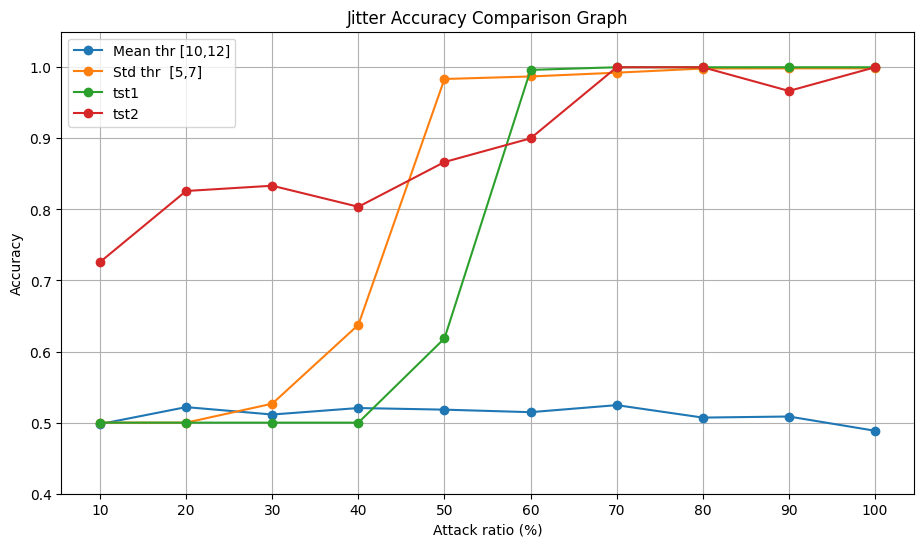


=== Accuracy (per attack_pct) ===
attack% | mean_thr |  std_thr |     tst1 |     tst2
-------------------------------------------------------
     10 | 0.4980 | 0.5000 | 0.5000 | 0.7259
     20 | 0.5218 | 0.5000 | 0.5000 | 0.8259
     30 | 0.5114 | 0.5267 | 0.5000 | 0.8333
     40 | 0.5206 | 0.6376 | 0.5000 | 0.8037
     50 | 0.5183 | 0.9835 | 0.6185 | 0.8667
     60 | 0.5147 | 0.9870 | 0.9963 | 0.9000
     70 | 0.5246 | 0.9924 | 1.0000 | 1.0000
     80 | 0.5071 | 0.9982 | 1.0000 | 1.0000
     90 | 0.5086 | 0.9985 | 1.0000 | 0.9667
    100 | 0.4886 | 0.9985 | 1.0000 | 1.0000


In [ ]:
# 8) 꺾은선 그래프 결과
df = pd.DataFrame({
    "attack_pct": attack_pcts,
    "mean_threshold_acc": acc_mean_thr,
    "std_threshold_acc":  acc_std_thr,
    "tst1_acc": acc_tst1,
    "tst2_acc": acc_tst2,
})
display(df)

plt.figure(figsize=(11, 6))
plt.plot(df["attack_pct"], df["mean_threshold_acc"], marker="o", label=f"Mean thr [{MEAN_LOW_THR},{MEAN_HIGH_THR}]")
plt.plot(df["attack_pct"], df["std_threshold_acc"],  marker="o", label=f"Std thr  [{STD_LOW_THR},{STD_HIGH_THR}]")
plt.plot(df["attack_pct"], df["tst1_acc"],          marker="o", label="tst1")
plt.plot(df["attack_pct"], df["tst2_acc"],          marker="o", label="tst2")

plt.xticks(attack_pcts)
plt.xlabel("Attack ratio (%)")
plt.ylabel("Accuracy")
plt.ylim(0.4, 1.05)
plt.grid(True)
plt.legend()
plt.title("Jitter Accuracy Comparison Graph")
plt.show()

# df 생성 후, print로 정확도 출력
print("\n=== Accuracy (per attack_pct) ===")
print(f"{'attack%':>7} | {'mean_thr':>8} | {'std_thr':>8} | {'tst1':>8} | {'tst2':>8}")
print("-" * 55)

for _, r in df.iterrows():
    print(f"{int(r['attack_pct']):7d} | "
          f"{r['mean_threshold_acc']:.4f} | "
          f"{r['std_threshold_acc']:.4f} | "
          f"{r['tst1_acc']:.4f} | "
          f"{r['tst2_acc']:.4f}")
